In [40]:
import nilearn.image
import pandas as pd

from mreyemove.analysis.glm.cli import construct_desc

from mreyemove.analysis.glm.config import GLMConfig
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root="/Users/zach/2025_RA/matthias/bids_sleepmreye",
    exclude_subjects=["01", "07", "09", "12"],
    tr=2.1,
    task="sleep",
    load_signal=False,
    load_eog=False,
    desc_add="clean-with-fd-clamped",
)
# config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original_atlas.yml")
# exp_results_df, exprun_data_df = mrio.load_roi_lme_results(desc_add=exp_desc_add)


In [131]:
import nibabel as nib 

x = nib.load("/Users/zach/2025_RA/matthias/bids_sleepmreye/derivatives/mreyemove/group/func/glm_brain/task-sleep_contrast-mreyemove_W-clean-with-fd-clamped-original-sleep/second_level_flame/flameo/stats/weights1.nii.gz")

d = x.get_fdata()

dir(x.header)
x.shape[-1]


27

In [142]:

config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original_sleep_atlas.yml")
desc_add = construct_desc(dataset=mrio, config=config)

from nilearn.decoding import searchlight
df = mrio.load_roi_lme_results(desc_add=desc_add)

df = df[0].sort_values(by=["p_fdr", "contrast"])
# df[df["contrast"] == "mreyemove_S"]

# df[df["label"] == "Hipp"]
df

,contrast,atlas,label,t_stat,p_val,p_fdr
16,mreyemove_W,cel_ret,OMV,5.679276,0.000100,0.000400
19,mreyemove_W,glasser,Calcarine Sulcus,5.309979,0.000100,0.000400
21,mreyemove_W,glasser,Frontal Eye Fields,2.959456,0.000200,0.000533
0,mreyemove,cel_ret,OMV,4.128152,0.000100,0.000800
9,mreyemove_S,cel_ret,VIIIb,3.499654,0.000900,0.007199
1,mreyemove,cel_ret,VIIIb,2.397413,0.005299,0.010599
3,mreyemove,glasser,Calcarine Sulcus,5.014227,0.004700,0.010599
5,mreyemove,glasser,Frontal Eye Fields,3.180002,0.004200,0.010599
8,mreyemove_S,cel_ret,OMV,3.984154,0.006399,0.025597
28,mreyemove_W-mreyemove_S,glasser,Central Sulcus,2.034093,0.010999,0.043996


In [114]:

import nilearn 
from nilearn.surface import load_surf_data
from matplotlib import pyplot as plt 
import numpy as np
from mreyemove.analysis.glm.atlas import fetch_atlas

subject = "08"
threshold = 4
contrasts = ["mreyemove_W"]
roi = [0, 180]

subject_data, _ = mrio.load_subject_level_glm_data(subject=subject, contrasts=contrasts, desc_add=desc_add)
t_map = subject_data[contrasts[0]].stat

atlas = fetch_atlas("glasser")
masker = nilearn.maskers.NiftiLabelsMasker(
    labels_img=atlas.maps,
    labels=atlas.labels,
    standardize=False,
    memory="nilearn_cache",
    verbose=0,
    strategy="mean",
)
vals = masker.fit_transform(t_map)
vals[roi].mean()


5.452380095453941

/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_16145/2286365203.py:33: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nilearn.plotting.plot_img_on_surf(


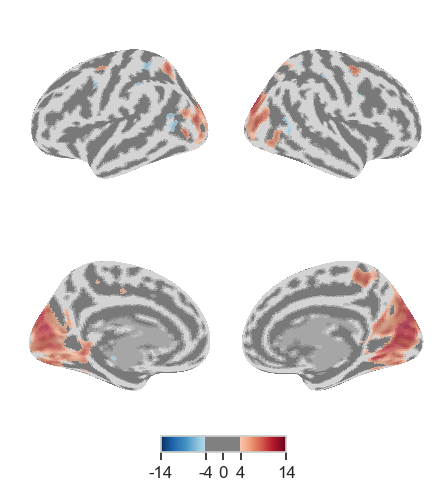

In [104]:
import nilearn 
from nilearn.surface import load_surf_data
from matplotlib import pyplot as plt 
import numpy as np
from mreyemove.analysis.glm.atlas import fetch_atlas

subject = "08"
threshold = 4
contrasts = ["mreyemove_W"]
roi = [0, 180]

subject_data, _ = mrio.load_subject_level_glm_data(subject=subject, contrasts=contrasts, desc_add=desc_add)
t_map = subject_data[contrasts[0]].stat

atlas = fetch_atlas("glasser")
masker = nilearn.maskers.NiftiLabelsMasker(
    labels_img=atlas.maps,
    labels=atlas.labels,
    standardize=False,
    memory="nilearn_cache",
    verbose=0,
    strategy="mean",
)
vals = masker.fit_transform(t_map)



# fsaverage = nilearn.datasets.fetch_surf_fsaverage("fsaverage5")
# 
# hemis_views = [
#   ("left", "lateral"), ("left", "medial"),
#   ("right", "lateral"), ("right", "medial"),
# ]
# 
# fig, axes = plt.subplots(1, 4, figsize=(20, 5), subplot_kw={"projection": "3d"})
# 
# for ax, (hemi, view) in zip(axes, hemis_views):
#   pial = fsaverage[f"infl_{hemi}"]
#   curv_map = load_surf_data(fsaverage[f"curv_{hemi}"])
#   bg_map = (np.sign(curv_map) + 1) / 4 + 0.25
# 
#   texture = nilearn.surface.vol_to_surf(
#       combined_img, fsaverage[f"pial_{hemi}"],
#       interpolation="nearest_most_frequent", radius=4,
#   )

nilearn.plotting.plot_img_on_surf(
  stat_map=t_map,
  surf_mesh="fsaverage5",
  # roi_map=texture,
  # hemi=hemi,
  # view=view,
  # bg_map=bg_map,
  bg_on_data=True,
  # title=f"{hemi.capitalize()} {view}",
  colorbar=True,
    threshold=threshold,
    inflate=True,
  # vmin=0,
  # vmax=n_rois,
  # cmap=cmap,
  # figure=fig,
  # axes=ax,
)

# legend_handles = [
#   Patch(facecolor=colors[i + 1], label=name)
#   for i, name in enumerate(roi_names)
# ]
# fig.legend(handles=legend_handles, loc="lower center", ncol=n_rois, fontsize=11)
# fig.subplots_adjust(bottom=0.12)
# fig.savefig("/Users/zach/Desktop/roi_surface_all.png", dpi=300, bbox_inches="tight")
plt.show()


In [161]:
    
exp_config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original_atlas.yml")
exp_desc_add = construct_desc(dataset=mrio, config=exp_config)

config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original_sleep_atlas.yml")
desc_add = construct_desc(dataset=mrio, config=config)


exp_results_df, exp_run_data_df = mrio.load_roi_lme_results(desc_add=exp_desc_add)
results_df, run_data_df = mrio.load_roi_lme_results(desc_add=desc_add)


exp_run_data_df[(exp_run_data_df["contrast"] == "mreyemove_W")]# .groupby("label")["t"].std()

,subject_i,contrast,label,cope,varcope,weight,atlas
189,0,mreyemove_W,Calcarine Sulcus,-0.484707,10404.330685,0.405102,glasser
190,0,mreyemove_W,Central Sulcus,18.838878,3867.694364,0.212750,glasser
191,0,mreyemove_W,Frontal Eye Fields,6.668898,3201.914497,0.236541,glasser
192,0,mreyemove_W,Supplementary Eye Fields,-9.814128,3231.979702,0.135075,glasser
193,0,mreyemove_W,OMV,28.617892,4553.530537,0.119875,cel_ret
...,...,...,...,...,...,...,...
373,26,mreyemove_W,Frontal Eye Fields,5.081130,12.778943,25.183615,glasser
374,26,mreyemove_W,Supplementary Eye Fields,2.463902,15.724052,22.262010,glasser
375,26,mreyemove_W,OMV,7.287701,13.498787,26.184006,cel_ret
376,26,mreyemove_W,VIIb,-5.309023,24.538414,51.583490,cel_ret


In [166]:
exp_run_data_df[(exp_run_data_df["contrast"] == "mreyemove_2")]#.groupby("label")["t_stat"].std()

,subject_i,contrast,label,cope,varcope,weight,atlas
567,0,mreyemove_2,Calcarine Sulcus,10.693931,107.678390,19.799835,glasser
568,0,mreyemove_2,Central Sulcus,-9.042446,35.343952,42.387960,glasser
569,0,mreyemove_2,Frontal Eye Fields,-5.982947,26.363360,27.554245,glasser
570,0,mreyemove_2,Supplementary Eye Fields,-8.007457,26.072083,66.634790,glasser
571,0,mreyemove_2,OMV,13.986485,40.165785,19.056429,cel_ret
...,...,...,...,...,...,...,...
709,20,mreyemove_2,Frontal Eye Fields,11.873957,425.634693,2.450312,glasser
710,20,mreyemove_2,Supplementary Eye Fields,-22.152440,529.776470,4.960380,glasser
711,20,mreyemove_2,OMV,36.260572,403.973777,4.257917,cel_ret
712,20,mreyemove_2,VIIb,10.183297,601.919426,5.494009,cel_ret


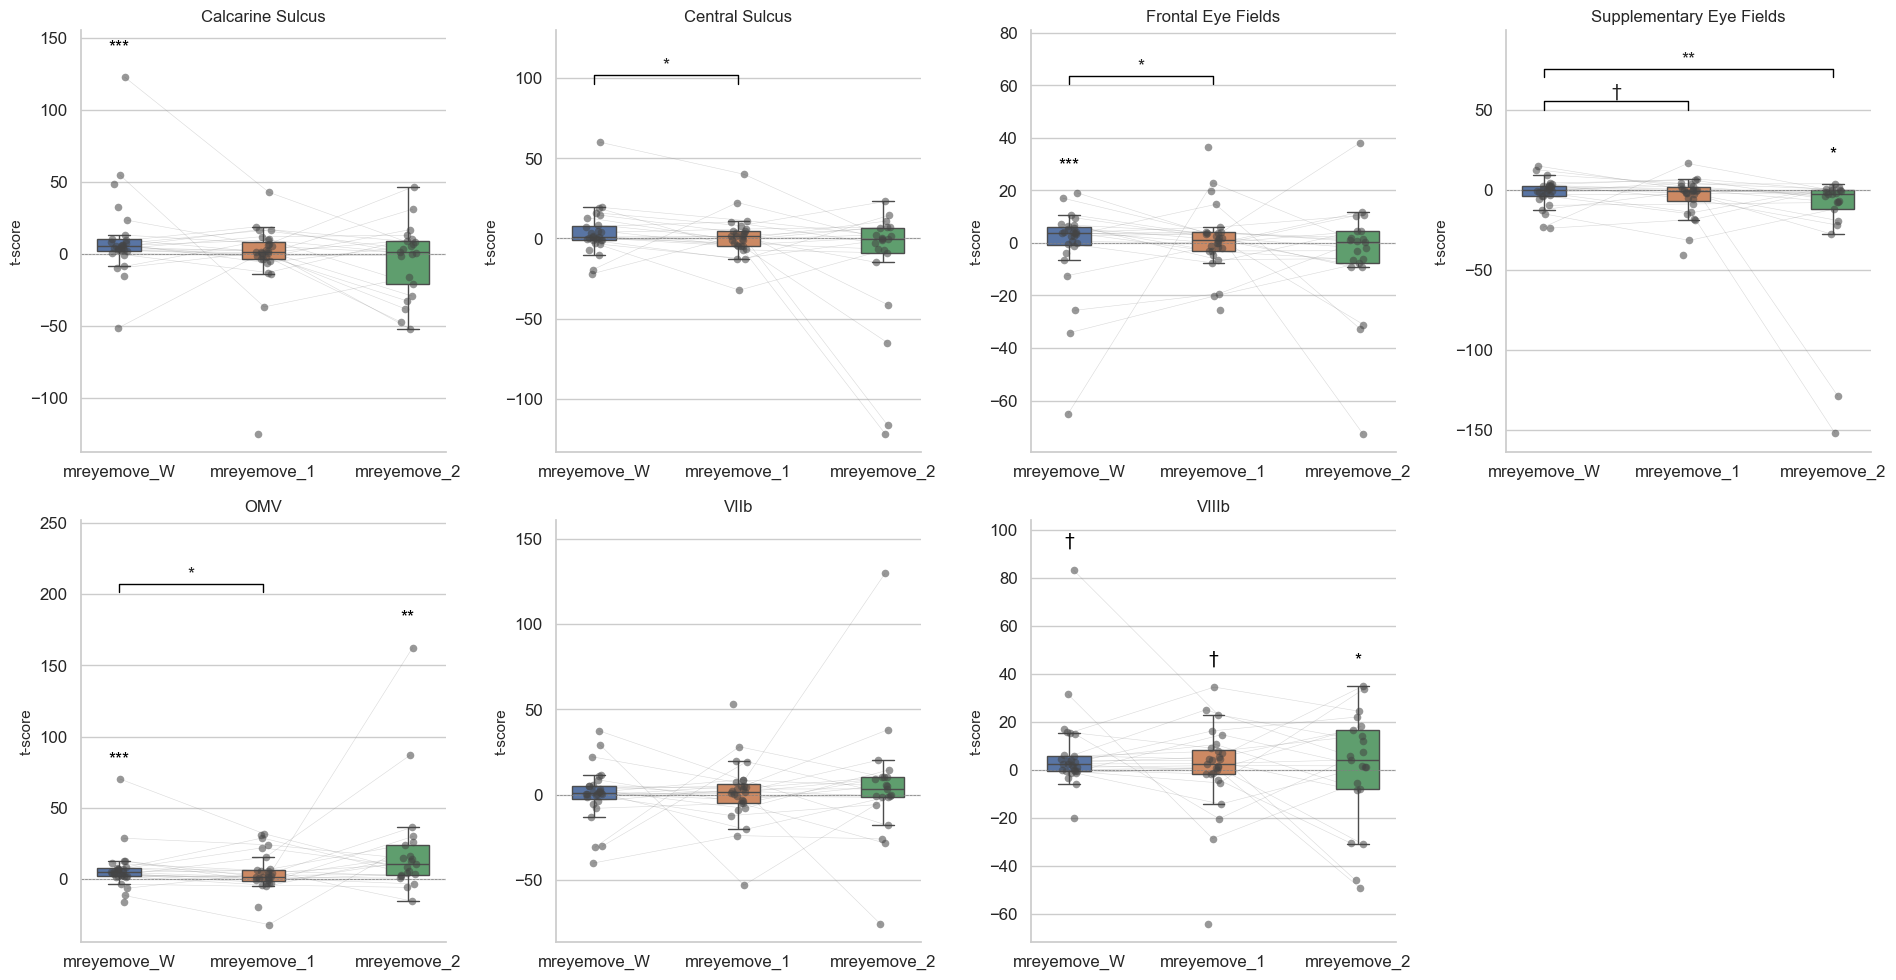

In [170]:
import seaborn as sns
import numpy as np 
sns.set_theme(style="whitegrid",font_scale=1.1)

def plot_roi_box(
  mrio,
  desc_add,
  save_path=None,
  contrasts=("mreyemove_W", "mreyemove_S"),
  diff_contrasts=None,
  alpha=0.05,
):
  """
  diff_contrasts: list of (contrast_name_in_results, idx_left, idx_right)
      e.g. [("mreyemove_W-mreyemove_S", 0, 1)]
      Auto-generated as "A-B" pairs if None.
  """
  if diff_contrasts is None:
      diff_contrasts = []
      for i in range(len(contrasts)):
          for j in range(i + 1, len(contrasts)):
              diff_contrasts.append((f"{contrasts[i]}-{contrasts[j]}", i, j))

  results_df, run_data_df = mrio.load_roi_lme_results(desc_add=desc_add)
  run_data_df["t_stat"] = run_data_df["cope"] #/ np.sqrt(run_data_df["varcope"])
  rois = run_data_df["label"].unique()
  colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]
  palette = {c: colors[i] for i, c in enumerate(contrasts)}

  # Filter to plottable ROIs
  plottable = []
  for roi in rois:
      roi_subj = run_data_df[run_data_df["label"] == roi]
      data_list = [roi_subj[roi_subj["contrast"] == c]["t_stat"].values for c in contrasts]
      if any(len(d) == 0 for d in data_list):
          print(f"Skipping {roi}: sizes = {[len(d) for d in data_list]}")
          continue
      plottable.append((roi, data_list))

  n = len(plottable)
  ncols = (n + 1) // 2
  nrows = 2 if n > 1 else 1

  fig, axes = plt.subplots(
      nrows, ncols,
      figsize=((3 + 0.6 * len(contrasts)) * ncols, 5 * nrows),
      squeeze=False,
  )

  for idx, (roi, data_list) in enumerate(plottable):
      row, col = divmod(idx, ncols)
      ax = axes[row, col]

      roi_df = run_data_df[
          (run_data_df["label"] == roi) & (run_data_df["contrast"].isin(contrasts))
      ].copy()

      sns.boxplot(
          data=roi_df,
          x="contrast",
          y="t_stat",
          # split=True,
          order=contrasts,
          hue="contrast",
          hue_order=contrasts,
          palette=palette,
          width=0.3,
          # capprops=dict(linewidth=0),
          # inner="quart",
          # cut=1,
          # linewidth=1.2,
          # saturation=0.9,
          showfliers=False,
          ax=ax,
      )

      positions = list(range(len(contrasts)))
      
      # Build subject-keyed data for paired lines
      roi_subj = run_data_df[run_data_df["label"] == roi]
      subj_data = {}  # {contrast_idx: {subject: t_stat}}
      for j, c in enumerate(contrasts):
          cdf = roi_subj[roi_subj["contrast"] == c]
          subj_data[j] = dict(zip(cdf["subject_i"], cdf["t_stat"]))

      rng = np.random.default_rng(42)
      # Per-subject jitter (consistent across contrasts)
      all_subjects = sorted(set().union(*(sd.keys() for sd in subj_data.values())))
      subj_jitter = {s: rng.uniform(-0.06, 0.06) for s in all_subjects}

      # Scatter points
      for j, (data, c) in enumerate(zip(data_list, contrasts)):
          subjects_in_c = list(subj_data[j].keys())
          jitter_vals = np.array([subj_jitter[s] for s in subjects_in_c])
          ax.scatter(
            np.full(len(data), j) + jitter_vals,
            data,
            color="#4444448c", alpha=0.55, s=30, zorder=3,
            edgecolors="white", linewidths=0,
          )

    # Paired lines only for subjects in ALL contrasts
      common_subjects = sorted(set.intersection(*(set(sd.keys()) for sd in subj_data.values())))
      for s in common_subjects:
        xs = [j + subj_jitter[s] for j in positions]
        ys = [subj_data[j][s] for j in positions]
        ax.plot(xs, ys, color="grey", alpha=0.3, linewidth=0.4, zorder=1)

      
      # rng = np.random.default_rng(42)
      # rng = np.random.default_rng(42)
      # jitters = [rng.uniform(-0.06, 0.06, size=len(data)) for data in data_list]
      # for j, (data, jitter) in enumerate(zip(data_list, jitters)):
      #   ax.scatter(
      #           np.full(len(data), j) + jitter,
      #           data,
      #           color="#4444448c", alpha=0.55, s=30, zorder=3,
      #           edgecolors="white", linewidths=0,
      #   )
      #   
      # for s in range(len(data_list[0])):
      #   xs = [j + jitters[j][s] for j in positions]
      #   ys = [data_list[j][s] for j in positions]
      #   ax.plot(xs, ys, color="grey", alpha=0.3, linewidth=0.4, zorder=1)

      sns.despine(ax=ax)
      # for i, subj in enumerate(roi_df["subject"].unique()):
      #     subj_vals = [roi_df[(roi_df["subject"] == subj) & (roi_df["contrast"] == c)]["t"].values[0] for c in contrasts]
      

      ax.set_xlabel("")
      ax.set_ylabel("t-score", fontsize=11)
      ax.set_title(roi, fontsize=12)
      ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
      ax.legend_.remove() if ax.legend_ else None

      positions = list(range(len(contrasts)))

      # Stars for significance vs zero
      for j, (data, c) in enumerate(zip(data_list, contrasts)):
          row_df = results_df[
              (results_df["label"] == roi) & (results_df["contrast"] == c)
          ]
          p_fdr = row_df["p_fdr"].values[0] if len(row_df) > 0 else np.nan
          if np.isfinite(p_fdr):
              star = _sig_stars(p_fdr, alpha)
              if star:
                  y_pos = data.max() + 0.08 * (data.max() - data.min())
                  ax.text(j, y_pos, star, ha="center", va="bottom", fontsize=13,
color="black")

      # Pairwise significance brackets
      all_vals = np.concatenate(data_list)
      y_range = np.max(all_vals) - np.min(all_vals)
      y_base = np.max(all_vals) + 0.2 * y_range
      bracket_step = 0.12 * y_range

      for k, (diff_name, i, j) in enumerate(diff_contrasts):
          row_df = results_df[
              (results_df["label"] == roi) & (results_df["contrast"] == diff_name)
          ]
          p_fdr = row_df["p_fdr"].values[0] if len(row_df) > 0 else np.nan
          if not np.isfinite(p_fdr):
              continue
          star = _sig_stars(p_fdr, alpha)
          if not star:
              continue

          y_bar = y_base + k * bracket_step
          h = 0.03 * y_range
          ax.plot([i, i, j, j], [y_bar, y_bar + h, y_bar + h, y_bar],
                  color="black", linewidth=1)
          ax.text((i + j) / 2, y_bar + h, star,
                  ha="center", va="bottom", fontsize=13)
                  
      ax.set_ylim(top=ax.get_ylim()[1] * 1.15)

  # Hide unused subplots
  for idx in range(n, nrows * ncols):
      row, col = divmod(idx, ncols)
      axes[row, col].set_visible(False)

  fig.tight_layout()
  if save_path is not None:
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
  else:
    plt.show()
      


plot_roi_box(
    mrio,
    desc_add=exp_desc_add,
    contrasts=("mreyemove_W", "mreyemove_1", "mreyemove_2"),
    # save_path='/Users/zach/Desktop/ROIs.png'
)


In [137]:
import seaborn as sns
def plot_roi_box(
  mrio,
  save_path=None,
  desc_add="",
  contrasts=("mreyemove_W", "mreyemove_S"),
  diff_contrasts=None,
  alpha=0.05,
):
  """
  diff_contrasts: list of (contrast_name_in_results, idx_left, idx_right)
      e.g. [("mreyemove_W-mreyemove_S", 0, 1)]
      Auto-generated as "A-B" pairs if None.
  """
  if diff_contrasts is None:
      diff_contrasts = []
      for i in range(len(contrasts)):
          for j in range(i + 1, len(contrasts)):
              diff_contrasts.append((f"{contrasts[i]}-{contrasts[j]}", i, j))

  results_df, run_data_df = mrio.load_roi_lme_results(desc_add=desc_add)
  rois = run_data_df["label"].unique()
  colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]
  palette = {c: colors[i] for i, c in enumerate(contrasts)}

  # Filter to plottable ROIs
  plottable = []
  for roi in rois:
      roi_subj = run_data_df[run_data_df["label"] == roi]
      data_list = [roi_subj[roi_subj["contrast"] == c]["emp_t"].values for c in contrasts]
      if any(len(d) == 0 for d in data_list):
          print(f"Skipping {roi}: sizes = {[len(d) for d in data_list]}")
          continue
      plottable.append((roi, data_list))

  n = len(plottable)
  ncols = (n + 1) // 2
  nrows = 2 if n > 1 else 1

  fig, axes = plt.subplots(
      nrows, ncols,
      figsize=((3 + 1.2 * len(contrasts)) * ncols, 5 * nrows),
      squeeze=False,
  )

  for idx, (roi, data_list) in enumerate(plottable):
      row, col = divmod(idx, ncols)
      ax = axes[row, col]

      roi_df = run_data_df[
          (run_data_df["label"] == roi) & (run_data_df["contrast"].isin(contrasts))
      ].copy()
      for ci, c in enumerate(contrasts):
          sns.violinplot(
              data=roi_df[roi_df["contrast"] == c],
              x="label",
              y="t",
              color=palette[c],
              # inner="quart",
              # cut=1,
              # linewidth=1.2,
              # saturation=0.9,
              split=True,
              alpha=0.7,
              ax=ax,
          )
      # 
      # sns.violinplot(
      #     data=roi_df,
      #     x="contrast",
      #     y="t",
      #     split=True,
      #     order=contrasts,
      #     hue="contrast",
      #     hue_order=contrasts,
      #     palette=palette,
      #     # inner="quart",
      #     # cut=1,
      #     # linewidth=1.2,
      #     # saturation=0.9,
      #     ax=ax,
      # )
      # 
      #     sns.stripplot(
      #         data=roi_df[roi_df["contrast"] == c],
      #         x="label",
      #         y="t",
      #         order=contrasts,
      #         hue="contrast",
      #         hue_order=contrasts,
      #         palette=["#444444"] * len(contrasts),
      #         alpha=0.45,
      #         size=4,
      #         jitter=0.08,
      #         dodge=False,
      #         ax=ax,
      #         legend=False,
      #     )

      ax.set_xlabel("")
      ax.set_ylabel("t-score", fontsize=11)
      ax.set_title(roi, fontsize=12)
      ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
#       ax.legend_.remove() if ax.legend_ else None
# 
#       positions = list(range(len(contrasts)))
# 
#       # Stars for significance vs zero
#       for j, (data, c) in enumerate(zip(data_list, contrasts)):
#           row_df = results_df[
#               (results_df["label"] == roi) & (results_df["contrast"] == c)
#           ]
#           p_fdr = row_df["p_fdr"].values[0] if len(row_df) > 0 else np.nan
#           if np.isfinite(p_fdr):
#               star = _sig_stars(p_fdr, alpha)
#               if star:
#                   y_pos = data.max() + 0.08 * (data.max() - data.min())
#                   ax.text(j, y_pos, star, ha="center", va="bottom", fontsize=13,
# color="black")
# 
#       # Pairwise significance brackets
#       all_vals = np.concatenate(data_list)
#       y_range = np.max(all_vals) - np.min(all_vals)
#       y_base = np.max(all_vals) + 0.2 * y_range
#       bracket_step = 0.12 * y_range
# 
#       for k, (diff_name, i, j) in enumerate(diff_contrasts):
#           row_df = results_df[
#               (results_df["label"] == roi) & (results_df["contrast"] == diff_name)
#           ]
#           p_fdr = row_df["p_fdr"].values[0] if len(row_df) > 0 else np.nan
#           if not np.isfinite(p_fdr):
#               continue
#           star = _sig_stars(p_fdr, alpha)
#           if not star:
#               continue
# 
#           y_bar = y_base + k * bracket_step
#           h = 0.03 * y_range
#           ax.plot([i, i, j, j], [y_bar, y_bar + h, y_bar + h, y_bar],
#                   color="black", linewidth=1)
#           ax.text((i + j) / 2, y_bar + h, star,
#                   ha="center", va="bottom", fontsize=13)

  # Hide unused subplots
  for idx in range(n, nrows * ncols):
      row, col = divmod(idx, ncols)
      axes[row, col].set_visible(False)

  fig.tight_layout()
  if save_path is not None:
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close(fig)
  else:
    plt.show()
      


plot_roi_box(
    mrio,
    desc_add=desc_add,
    contrasts=("mreyemove_W", "mreyemove_S"),
    # save_path='/Users/zach/Desktop/ROIs.svg'
)


KeyError: 't_emp'

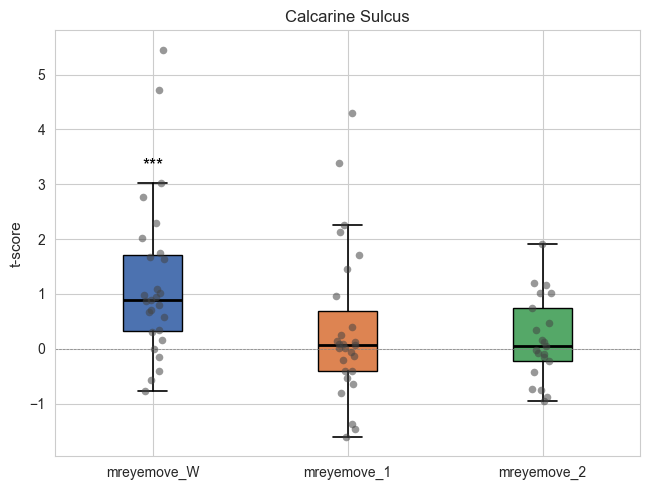

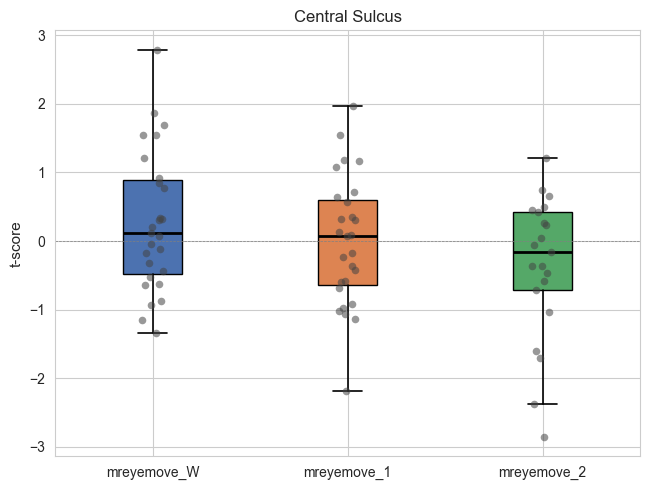

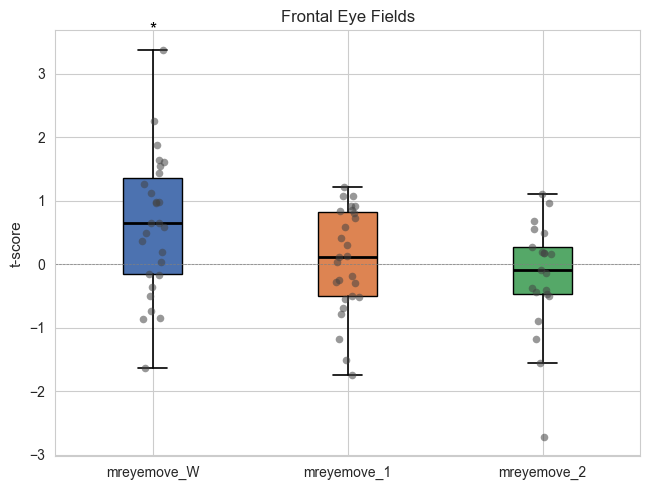

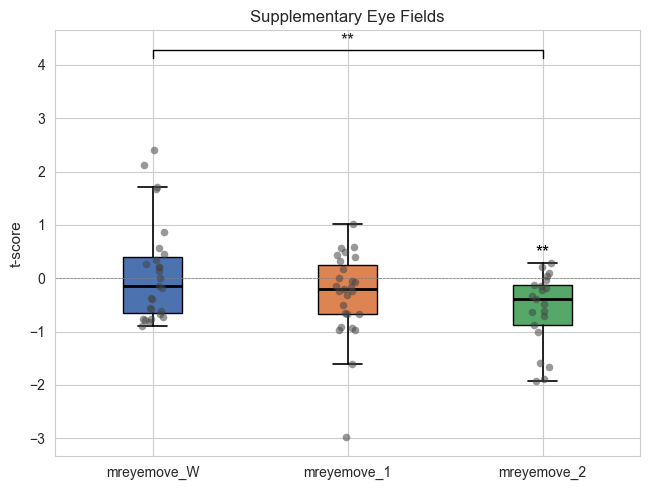

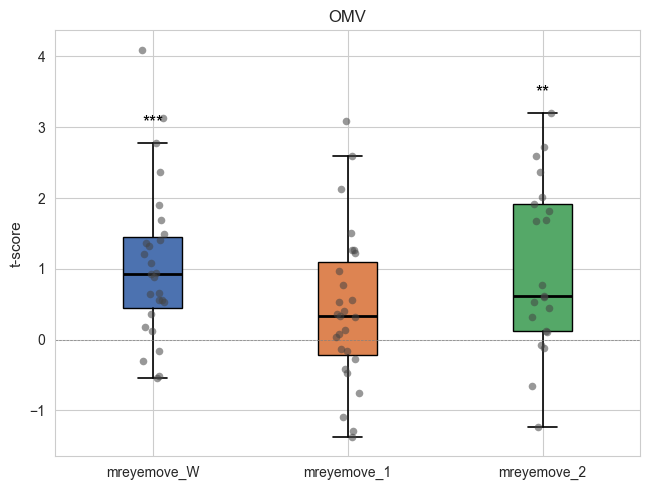

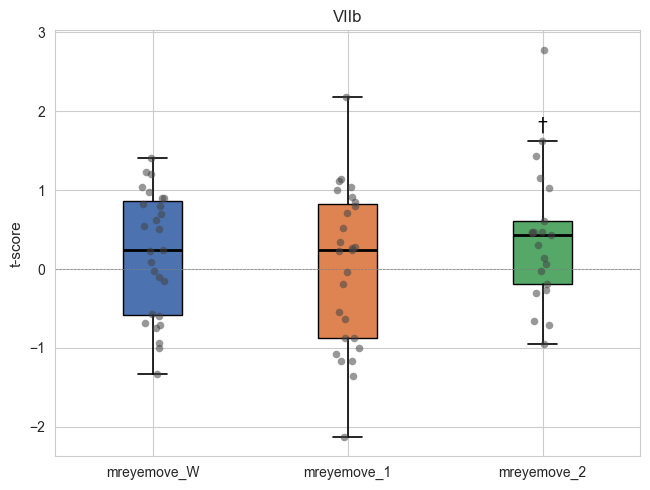

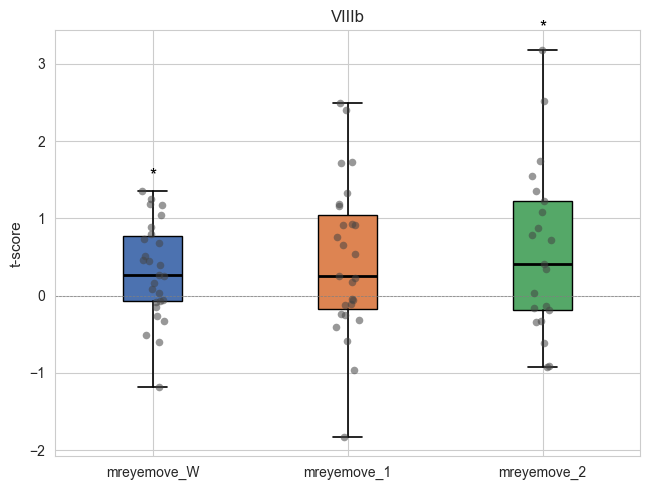

In [33]:
import numpy as np
import matplotlib.pyplot as plt


def plot_roi_box(
  mrio,
  desc_add="",
  contrasts=("mreyemove_W", "mreyemove_S"),
  diff_contrasts=None,
  alpha=0.05,
):
  """
  diff_contrasts: list of (contrast_name_in_results, idx_left, idx_right)
      e.g. [("mreyemove_W-mreyemove_S", 0, 1)]
      Auto-generated as "A-B" pairs if None.
  """
  if diff_contrasts is None:
      diff_contrasts = []
      for i in range(len(contrasts)):
          for j in range(i + 1, len(contrasts)):
              diff_contrasts.append((f"{contrasts[i]}-{contrasts[j]}", i, j))

  results_df, run_data_df = mrio.load_roi_lme_results(desc_add=desc_add)
  rois = run_data_df["label"].unique()
  colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]

  for roi in rois:
      roi_subj = run_data_df[run_data_df["label"] == roi]

      data_list = []
      for c in contrasts:
          data_list.append(roi_subj[roi_subj["contrast"] == c]["t"].values)

      if any(len(d) == 0 for d in data_list):
          if any(len(d) == 0 for d in data_list):
              print(f"Skipping {roi}: sizes = {[len(d) for d in data_list]}")
              print(run_data_df["contrast"].unique())
              continue
          continue

      positions = list(range(len(contrasts)))
      fig, ax = plt.subplots(figsize=(3 + 1.2 * len(contrasts), 5))

      # Boxplot
      bp = ax.boxplot(
          data_list,
          positions=positions,
          widths=0.3,
          patch_artist=True,
          showfliers=False,
          medianprops=dict(color="black", linewidth=2),
          whiskerprops=dict(linewidth=1.2),
          capprops=dict(linewidth=1.2),
          zorder=2,
      )
      for patch, color in zip(bp["boxes"], colors):
          patch.set_facecolor(color)
          patch.set_alpha(1)

      # Subject dots
      rng = np.random.default_rng(42)
      for j, data in zip(positions, data_list):
          jitter = rng.uniform(-0.06, 0.06, size=len(data))
          ax.scatter(
              np.full(len(data), j) + jitter,
              data,
              color="#4444448c", alpha=0.55, s=30, zorder=3,
              edgecolors="white", linewidths=0,
          )

      ax.set_xticks(positions)
      ax.set_xticklabels(contrasts, fontsize=10)
      ax.set_ylabel("t-score", fontsize=11)
      ax.set_title(roi, fontsize=12)
      ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")

      # Stars above each box for significance vs zero
      for j, (data, c) in enumerate(zip(data_list, contrasts)):
          row = results_df[
              (results_df["label"] == roi) & (results_df["contrast"] == c)
          ]
          p_fdr = row["p_fdr"].values[0] if len(row) > 0 else np.nan
          if np.isfinite(p_fdr):
              star = _sig_stars(p_fdr, alpha)
              if star:
                  iqr = np.subtract(*np.percentile(data, [75, 25]))
                  whisker_top = np.max(data[data <= np.percentile(data, 75) + 1.5 * iqr])
                  ax.text(j, whisker_top + 0.05 * abs(whisker_top) if whisker_top != 0 else
0.05,
                          star, ha="center", va="bottom", fontsize=13, color="black")

      # Pairwise significance brackets — stacked
      all_vals = np.concatenate(data_list)
      y_range = np.max(all_vals) - np.min(all_vals)
      y_base = np.max(all_vals) + 0.2 * y_range
      bracket_step = 0.12 * y_range

      for k, (diff_name, i, j) in enumerate(diff_contrasts):
          row = results_df[
              (results_df["label"] == roi) & (results_df["contrast"] == diff_name)
          ]
          p_fdr = row["p_fdr"].values[0] if len(row) > 0 else np.nan
          if not np.isfinite(p_fdr):
              continue
          star = _sig_stars(p_fdr, alpha)
          if not star:
              continue

          y_bar = y_base + k * bracket_step
          h = 0.03 * y_range
          ax.plot([i, i, j, j], [y_bar, y_bar + h, y_bar + h, y_bar],
                  color="black", linewidth=1)
          ax.text((i + j) / 2, y_bar + h, star,
                  ha="center", va="bottom", fontsize=13)

      fig.tight_layout()
      plt.show()


def _sig_stars(p, alpha=0.05):
  if p < alpha / 50:
      return "***"
  if p < alpha / 5:
      return "**"
  if p < alpha:
      return "*"
  if p < 0.1:
      return "†"
  return ""


plot_roi_box(
  mrio,
  desc_add=exp_desc_add,
  contrasts=("mreyemove_W", "mreyemove_1", "mreyemove_2"),
)




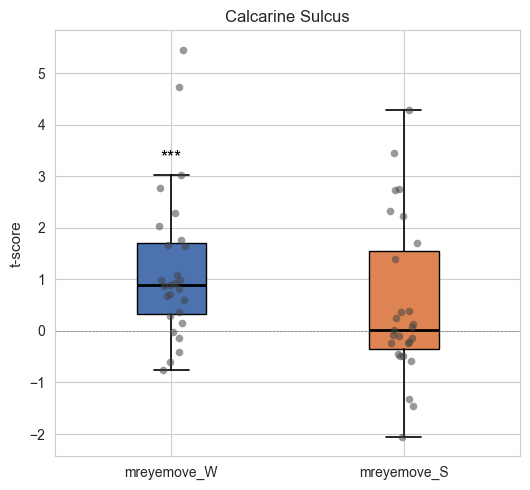

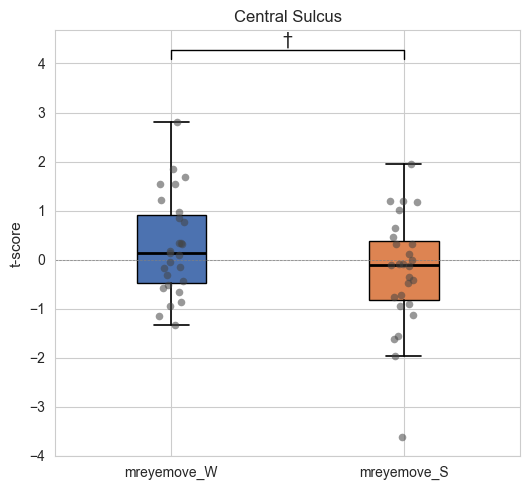

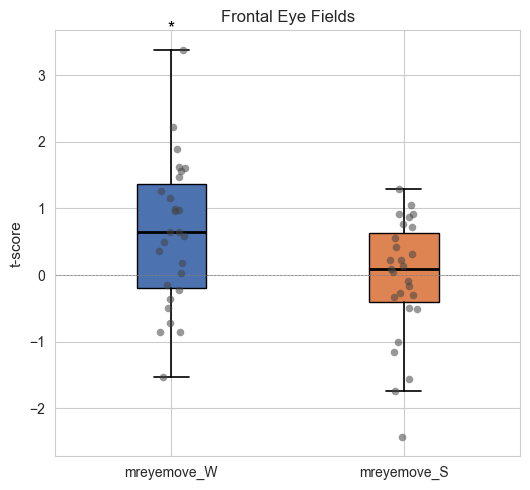

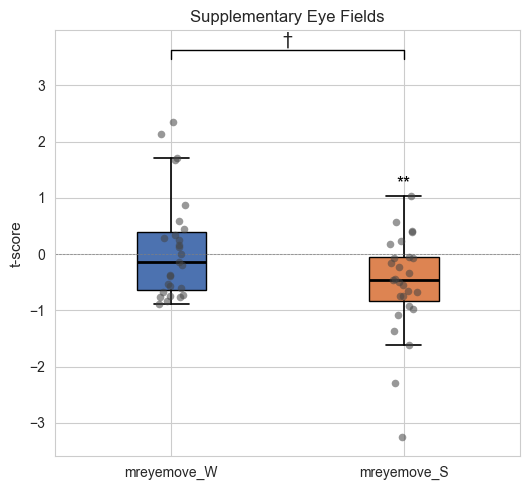

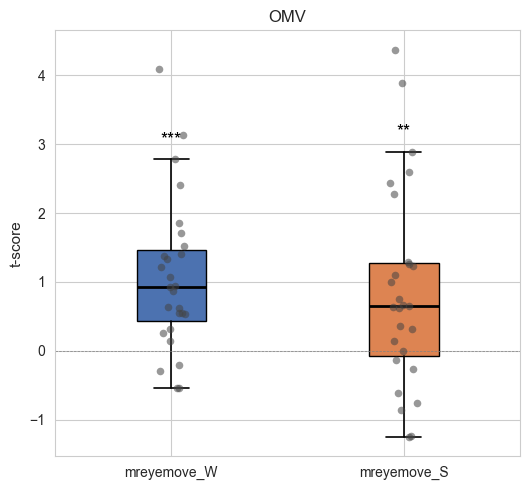

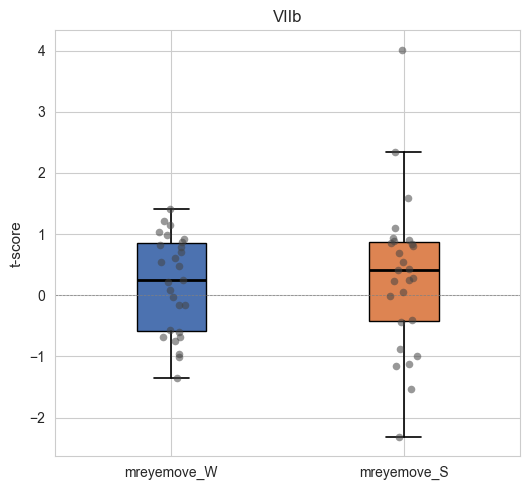

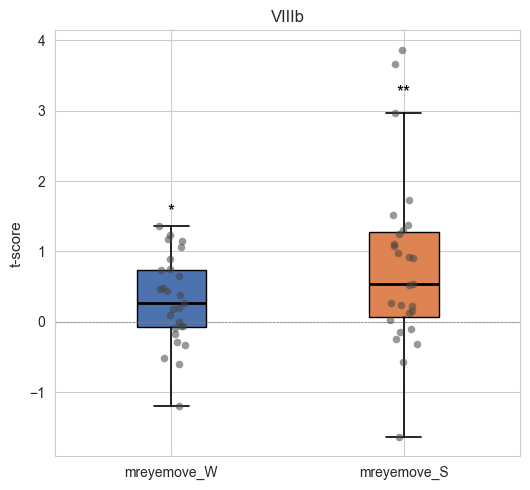

In [34]:

plot_roi_box(
  mrio,
  desc_add=desc_add,
  contrasts=("mreyemove_W", "mreyemove_S"),
)


NameError: name 'run_data_df' is not defined

In [28]:
mrio.load_roi_lme_results(desc_add=desc_add)[1]

,subject,contrast,label,t,atlas
0,10,mreyemove,V1,0.668300,glasser
1,10,mreyemove,EF,0.945262,glasser
2,10,mreyemove,Hipp,0.884855,ho_sub
3,10,mreyemove_W,V1,0.818999,glasser
4,10,mreyemove_W,EF,0.979132,glasser
...,...,...,...,...,...
319,28,mreyemove_S,EF,-0.086582,glasser
320,28,mreyemove_S,Hipp,-0.003690,ho_sub
321,28,mreyemove_W-mreyemove_S,V1,0.414466,glasser
322,28,mreyemove_W-mreyemove_S,EF,-0.399855,glasser


In [13]:
from nilearn.image import resample_to_img
from mreyemove.analysis.glm.atlas import fetch_atlas
from nilearn.maskers import NiftiLabelsMasker
import nibabel as nib, numpy as np

atlas = fetch_atlas("glasser")
atlas_data = atlas.maps.get_fdata().astype(int)

# 1. Sanity: how many parcels? Any gaps?
uniq = np.unique(atlas_data)
uniq = uniq[uniq != 0]
print("n unique non-zero:", len(uniq), "| len(labels):", len(atlas.labels))
print("min/max:", uniq.min(), uniq.max(), "| contiguous:", (uniq == np.arange(uniq.min(),uniq.max()+1)).all())

# 2. Is the presumed L_V1 integer actually in the calcarine?
l_v1_pos = atlas.labels.index("L_V1_ROI")   # positional index into labels
l_v1_int = uniq[l_v1_pos]                   # what integer nilearn will pair with it
xyz = np.argwhere(atlas_data == l_v1_int).mean(axis=0)
print("L_V1 integer:", l_v1_int, "centroid (vox):", xyz)
# Convert to mm and check: left calcarine is roughly MNI [-10, -85, 5]

# 3. Direct cope extraction vs masker
cope = mrio.load_run_level_glm_data(
            subject="10", run="1", contrasts=["mreyemove_W"], desc_add=desc_add
        )[0]["mreyemove_W"].cope
atlas_on_cope = resample_to_img(atlas.maps, cope, interpolation="nearest")
data_r = atlas_on_cope.get_fdata().astype(int)

direct = cope.get_fdata()[data_r == l_v1_int].mean()
n_vox  = int((data_r == l_v1_int).sum())

masker = NiftiLabelsMasker(labels_img=atlas.maps, labels=atlas.labels, strategy="mean")
masker.fit(cope)
vals = masker.transform(cope).ravel()
via_masker = vals[list(masker.region_names_.values()).index("L_V1_ROI")]

print(f"direct: {direct:.4f} over {n_vox} vox  |  masker: {via_masker:.4f}")

# direct = cope.get_fdata()[atlas_data == l_v1_int].mean()
# 
# masker = NiftiLabelsMasker(labels_img=atlas.maps, labels=atlas.labels, strategy="mean")
# masker.fit(cope)
# out = masker.transform(cope).ravel()
# region_names = list(masker.region_names_.values())
# via_masker = out[region_names.index("L_V1_ROI")]
# 
# print(f"direct: {direct:.3f}  |  via masker: {via_masker:.3f}")

n unique non-zero: 360 | len(labels): 360
min/max: 1 360 | contiguous: True
L_V1 integer: 1 centroid (vox): [86.04666151 46.66524878 80.05297757]


/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_80493/3680742706.py:26: FutureWarning: 'force_resample' will be set to 'True' by default in Nilearn 0.13.0.
Use 'force_resample=True' to suppress this warning.
  atlas_on_cope = resample_to_img(atlas.maps, cope, interpolation="nearest")
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_80493/3680742706.py:26: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  atlas_on_cope = resample_to_img(atlas.maps, cope, interpolation="nearest")


direct: 4.1522 over 439 vox  |  masker: 4.1522


In [19]:
# Per-subject V1 mean (and per-run distribution)
results, roi_data = mrio.load_roi_lme_results(desc_add=desc_add)
# roi_data
v1 = roi_data.query("contrast == 'mreyemove_W' and label == 'V1' and atlas == 'glasser'")
print(f"n rows: {len(v1)}, n subjects: {v1['subject'].nunique()}")
print(v1.groupby("subject")["cope"].agg(["mean", "std", "count"]))
print(f"\nGrand mean: {v1['cope'].mean():.4f}, std: {v1['cope'].std():.4f}")
print(f"Subjects with mean > 0: {(v1.groupby('subject')['cope'].mean() > 0).sum()}")
# 
# LME output for V1
print("\n--- LME result for V1 mreyemove_W ---")
print(results.query("contrast == 'mreyemove_W' and label == 'V1'"))


n rows: 135, n subjects: 27
               mean         std  count
subject                               
3         -1.401306  107.860739      3
4          2.636730   21.216811      6
5         13.030612    9.186912      6
6          6.538060    2.701337      4
8         10.485187    7.460163      7
10        24.119170   36.655262      6
11         5.862209    1.370812      2
13         2.523351    7.193991      4
14         0.186143    8.793267      5
15       -50.795001   87.226131      5
16       -11.091233   46.019686      3
17         7.481068    7.990427      6
18         5.483119    8.781400      5
19        -8.635546   62.655847      3
20         3.410305    8.801996      4
22         4.264017    3.157379      7
23        53.019386   83.362066      2
24         8.223239    9.375705      3
25       122.901898  105.199143      6
26         2.721308    4.150696      6
27         4.716325    3.107248      5
28         5.176077   12.435288      5
29         1.750905    1.905338     

In [20]:

per_sub = v1.groupby("subject")["cope"].mean()
from scipy import stats
t, p = stats.ttest_1samp(per_sub, 0)
print(f"subject-level one-sample t-test: t={t:.2f}, p={p:.4f}, n={len(per_sub)}")


subject-level one-sample t-test: t=1.88, p=0.0709, n=27


In [11]:
atlas_data.shape

(193, 229, 193)

In [3]:
from nilearn import datasets

atlas = datasets.fetch_atlas_destrieux_2009(lateralized=False)
atlas.labels

[fetch_atlas_destrieux_2009] Dataset found in /Users/zach/nilearn_data/destrieux_2009

/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_42312/148059813.py:3: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index        name
    42 Medial_wall

  atlas = datasets.fetch_atlas_destrieux_2009(lateralized=False)


['Unknown',
 'G_and_S_frontomargin',
 'G_and_S_occipital_inf',
 'G_and_S_paracentral',
 'G_and_S_subcentral',
 'G_and_S_transv_frontopol',
 'G_and_S_cingul-Ant',
 'G_and_S_cingul-Mid-Ant',
 'G_and_S_cingul-Mid-Post',
 'G_cingul-Post-dorsal',
 'G_cingul-Post-ventral',
 'G_cuneus',
 'G_front_inf-Opercular',
 'G_front_inf-Orbital',
 'G_front_inf-Triangul',
 'G_front_middle',
 'G_front_sup',
 'G_Ins_lg_and_S_cent_ins',
 'G_insular_short',
 'G_occipital_middle',
 'G_occipital_sup',
 'G_oc-temp_lat-fusifor',
 'G_oc-temp_med-Lingual',
 'G_oc-temp_med-Parahip',
 'G_orbital',
 'G_pariet_inf-Angular',
 'G_pariet_inf-Supramar',
 'G_parietal_sup',
 'G_postcentral',
 'G_precentral',
 'G_precuneus',
 'G_rectus',
 'G_subcallosal',
 'G_temp_sup-G_T_transv',
 'G_temp_sup-Lateral',
 'G_temp_sup-Plan_polar',
 'G_temp_sup-Plan_tempo',
 'G_temporal_inf',
 'G_temporal_middle',
 'Lat_Fis-ant-Horizont',
 'Lat_Fis-ant-Vertical',
 'Lat_Fis-post',
 'Medial_wall',
 'Pole_occipital',
 'Pole_temporal',
 'S_calcarin

In [16]:
from nilearn.maskers import NiftiLabelsMasker
# from mreyemove.analysis.glm.config import fetch_atlas
import numpy as np 

atlas_name = "juelich"
atlas = fetch_atlas(atlas_name)
masker = NiftiLabelsMasker(
    labels_img=atlas.maps,
    standardize=False,
    memory="nilearn_cache",
    verbose=0,
)

labels = atlas.labels
sorted(labels)

ImportError: cannot import name 'fetch_atlas' from 'mreyemove.analysis.glm.config' (/Users/zach/2025_RA/matthias/eyemove_and_sleep/MReyeMove/src/mreyemove/analysis/glm/config.py)

In [28]:

import urllib.request
from pathlib import Path
import nibabel as nib





def fetch_glasser_mmp1() -> dict:
    CACHE_DIR = Path.home() / ".cache" / "atlases" / "glasser_mmp1"
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    
    CANLAB_BASE = (
        "https://github.com/canlab/Neuroimaging_Pattern_Masks/raw/refs/heads/master"
        "/Atlases_and_parcellations/2016_Glasser_Nature_HumanConnectomeParcellation"
    )
    
    ATLAS_FNAME = "glasser_MNI152NLin2009cAsym_labels_p20.nii.gz"
    CACHE_DIR = Path.home() / ".cache" / "atlases" / "glasser_mmp1"
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    # Download labels from canlab GitHub
    labels = {}
    idx = 1
    for hemi in ("lctx", "rctx"):
        fname = f"{hemi}_labels.txt"
        out = CACHE_DIR / fname
        if not out.exists():
            print(f"Downloading {fname} ...")
            urllib.request.urlretrieve(f"{CANLAB_BASE}/{fname}", out)
        with open(out) as f:
            for line in f:
                name = line.strip().split()[0]  # e.g. "L_V1_ROI"
                labels[idx] = name
                idx += 1

    # Download atlas NIfTI from figshare
    atlas_path = CACHE_DIR / ATLAS_FNAME
    if not atlas_path.exists():
        raise ValueError("Atlas does not exist. Please download from https://figshare.com/ndownloader/files/43043683 and save to Path.home()/.cache/atlases/glasser_mmp1")

    img = nib.load(atlas_path)
    return {"maps": img, "labels": labels}


atlas = fetch_glasser_mmp1()
print(f"Shape: {atlas['maps'].shape}")
print(f"N labels: {len(atlas['labels'])}")
for idx, name in atlas["labels"].items():
    # if any(k in name for k in ["V1", "6ma", "6mp", "4_", "3b", "_1_", "_2_", "3a"]):
    print(f"  {idx}: {name}")

Shape: (193, 229, 193)
N labels: 360
  1: L_V1_ROI
  2: L_MST_ROI
  3: L_V6_ROI
  4: L_V2_ROI
  5: L_V3_ROI
  6: L_V4_ROI
  7: L_V8_ROI
  8: L_4_ROI
  9: L_3b_ROI
  10: L_FEF_ROI
  11: L_PEF_ROI
  12: L_55b_ROI
  13: L_V3A_ROI
  14: L_RSC_ROI
  15: L_POS2_ROI
  16: L_V7_ROI
  17: L_IPS1_ROI
  18: L_FFC_ROI
  19: L_V3B_ROI
  20: L_LO1_ROI
  21: L_LO2_ROI
  22: L_PIT_ROI
  23: L_MT_ROI
  24: L_A1_ROI
  25: L_PSL_ROI
  26: L_SFL_ROI
  27: L_PCV_ROI
  28: L_STV_ROI
  29: L_7Pm_ROI
  30: L_7m_ROI
  31: L_POS1_ROI
  32: L_23d_ROI
  33: L_v23ab_ROI
  34: L_d23ab_ROI
  35: L_31pv_ROI
  36: L_5m_ROI
  37: L_5mv_ROI
  38: L_23c_ROI
  39: L_5L_ROI
  40: L_24dd_ROI
  41: L_24dv_ROI
  42: L_7AL_ROI
  43: L_SCEF_ROI
  44: L_6ma_ROI
  45: L_7Am_ROI
  46: L_7PL_ROI
  47: L_7PC_ROI
  48: L_LIPv_ROI
  49: L_VIP_ROI
  50: L_MIP_ROI
  51: L_1_ROI
  52: L_2_ROI
  53: L_3a_ROI
  54: L_6d_ROI
  55: L_6mp_ROI
  56: L_6v_ROI
  57: L_p24pr_ROI
  58: L_33pr_ROI
  59: L_a24pr_ROI
  60: L_p32pr_ROI
  61: L_a24_ROI

In [157]:
fetch_atlas("ho_sub").labels

[fetch_atlas_harvard_oxford] Dataset found in /Users/zach/nilearn_data/fsl

['Background',
 'Left Cerebral White Matter',
 'Left Cerebral Cortex',
 'Left Lateral Ventricle',
 'Left Thalamus',
 'Left Caudate',
 'Left Putamen',
 'Left Pallidum',
 'Brain-Stem',
 'Left Hippocampus',
 'Left Amygdala',
 'Left Accumbens',
 'Right Cerebral White Matter',
 'Right Cerebral Cortex',
 'Right Lateral Ventricle',
 'Right Thalamus',
 'Right Caudate',
 'Right Putamen',
 'Right Pallidum',
 'Right Hippocampus',
 'Right Amygdala',
 'Right Accumbens']

In [18]:
from mreyemove.analysis.glm.atlas import fetch_atlas
atlas = fetch_atlas("schaefer500")
atlas.labels

[fetch_atlas_schaefer_2018] Dataset found in /Users/zach/nilearn_data/schaefer_2018

['Background',
 '7Networks_LH_Vis_1',
 '7Networks_LH_Vis_2',
 '7Networks_LH_Vis_3',
 '7Networks_LH_Vis_4',
 '7Networks_LH_Vis_5',
 '7Networks_LH_Vis_6',
 '7Networks_LH_Vis_7',
 '7Networks_LH_Vis_8',
 '7Networks_LH_Vis_9',
 '7Networks_LH_Vis_10',
 '7Networks_LH_Vis_11',
 '7Networks_LH_Vis_12',
 '7Networks_LH_Vis_13',
 '7Networks_LH_Vis_14',
 '7Networks_LH_Vis_15',
 '7Networks_LH_Vis_16',
 '7Networks_LH_Vis_17',
 '7Networks_LH_Vis_18',
 '7Networks_LH_Vis_19',
 '7Networks_LH_Vis_20',
 '7Networks_LH_Vis_21',
 '7Networks_LH_Vis_22',
 '7Networks_LH_Vis_23',
 '7Networks_LH_Vis_24',
 '7Networks_LH_Vis_25',
 '7Networks_LH_Vis_26',
 '7Networks_LH_Vis_27',
 '7Networks_LH_Vis_28',
 '7Networks_LH_Vis_29',
 '7Networks_LH_Vis_30',
 '7Networks_LH_Vis_31',
 '7Networks_LH_Vis_32',
 '7Networks_LH_Vis_33',
 '7Networks_LH_Vis_34',
 '7Networks_LH_Vis_35',
 '7Networks_LH_Vis_36',
 '7Networks_LH_Vis_37',
 '7Networks_LH_Vis_38',
 '7Networks_LH_Vis_39',
 '7Networks_LH_SomMot_1',
 '7Networks_LH_SomMot_2',
 '7Net

/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_21521/4172803517.py:49: FutureWarning: The 'nearest' interpolation method will be deprecated in 0.13.0. To disable this warning, select either 'linear' or 'nearest_most_frequent'. If your image is a deterministic atlas 'nearest_most_frequent' is recommended. Otherwise, use 'linear'. See the documentation for more information.
  texture = surface.vol_to_surf(combined_img, pial, interpolation="nearest")
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_21521/4172803517.py:53: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_roi(


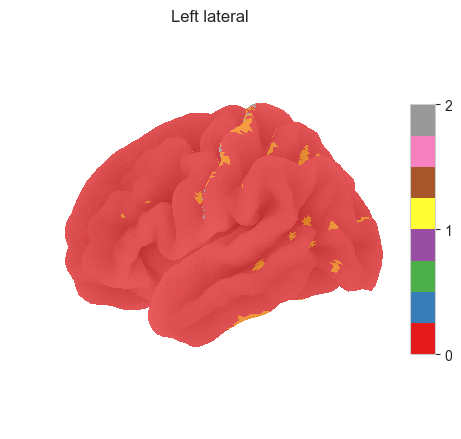

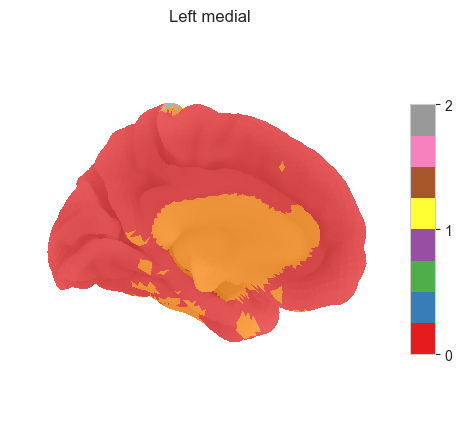

/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_21521/4172803517.py:49: FutureWarning: The 'nearest' interpolation method will be deprecated in 0.13.0. To disable this warning, select either 'linear' or 'nearest_most_frequent'. If your image is a deterministic atlas 'nearest_most_frequent' is recommended. Otherwise, use 'linear'. See the documentation for more information.
  texture = surface.vol_to_surf(combined_img, pial, interpolation="nearest")
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_21521/4172803517.py:53: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_roi(


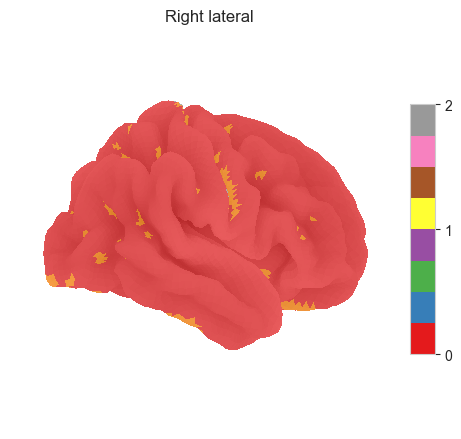

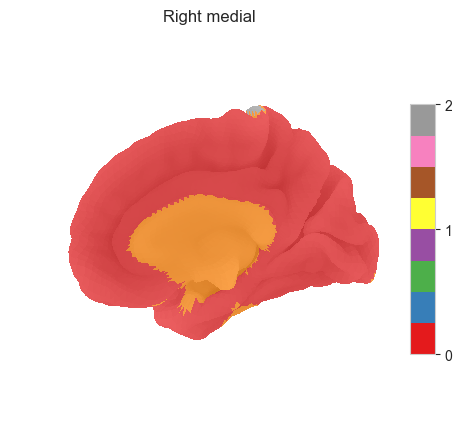

In [19]:
from mreyemove.analysis.glm.atlas import fetch_atlas
atlas = fetch_atlas("glasser")

import numpy as np
import nibabel as nib
from nilearn import datasets, plotting, surface

# ── configuration ────────────────────────────────────────────────────────────

ROIS_TO_PLOT = {
    "V1":  ["L_V1_ROI", "R_V1_ROI"],
    # "M1":  ["L_4_ROI", "R_4_ROI"],
    # "S1":  ["L_3a_ROI", "R_3a_ROI", "L_3b_ROI", "R_3b_ROI",
    #         "L_1_ROI",  "R_1_ROI",  "L_2_ROI",  "R_2_ROI"],
    # "SMA": ["L_6ma_ROI", "R_6ma_ROI", "L_6mp_ROI", "R_6mp_ROI"],
    "FEF": ["L_FEF_ROI", "R_FEF_ROI"]
}

# ── build labeled volume ──────────────────────────────────────────────────────

atlas_img  = atlas.maps
atlas_data = atlas_img.get_fdata()
label_to_idx = {v: k for k, v in enumerate(atlas.labels)}

combined = np.zeros(atlas_data.shape, dtype=np.int32)
for roi_idx, (roi_name, parcel_names) in enumerate(ROIS_TO_PLOT.items(), start=1):
    indices = [label_to_idx[p] for p in parcel_names if p in label_to_idx]
    if not indices:
        print(f"Warning: no parcels found for {roi_name}")
        continue
    combined[np.isin(atlas_data, indices)] = roi_idx

combined_img = nib.Nifti1Image(combined, atlas_img.affine)

# ── fetch fsaverage surface ───────────────────────────────────────────────────

fsaverage = datasets.fetch_surf_fsaverage("fsaverage5")

# ── plot each hemisphere ──────────────────────────────────────────────────────

n_rois  = len(ROIS_TO_PLOT)
roi_names = list(ROIS_TO_PLOT.keys())

for hemi, views in [("left", ["lateral", "medial"]), ("right", ["lateral", "medial"])]:
    pial    = fsaverage[f"pial_{hemi}"]
    sulcal  = fsaverage[f"sulc_{hemi}"]

    # project volume onto surface
    texture = surface.vol_to_surf(combined_img, pial, interpolation="nearest")
    texture = np.round(texture).astype(np.int32).astype(np.float32)

    for view in views:
        fig = plotting.plot_surf_roi(
            surf_mesh=pial,
            roi_map=texture,
            hemi=hemi,
            view=view,
            bg_map=sulcal,
            bg_on_data=True,
            title=f"{hemi.capitalize()} {view}",
            colorbar=True,
            vmin=0,
            vmax=n_rois,
            cmap="Set1",
        )
        # fig.savefig(f"roi_surface_{hemi}_{view}.png", dpi=150, bbox_inches="tight")
        plotting.show()

In [20]:

from mreyemove.plotting.glm import custom_cmap
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpecFromSubplotSpec, GridSpec
from nilearn.plotting.surface._matplotlib_backend import _plot_surf, _colorbar_from_array, _get_ticks
from nilearn.surface import load_surf_data


def plot_surface_rois(
    roi_maps,
    surf_mesh="fsaverage7",
    cmap=None,
    threshold=None,
    symmetric_cbar="auto",
    cbar_tick_format="%.1f",
    title=None,
    inflate=False,
    output_file=None,
    bg_on_data=True,
):
    """
    Plot surface searchlight correlation maps using the same rendering
    pipeline as glm_surface.py (internal _plot_surf).
    """
    map_data = roi_maps.get_fdata()
    vmin = 0
    vmax = np.max(map_data)

    fsaverage = datasets.fetch_surf_fsaverage(mesh=surf_mesh)
    hemis = ["left", "right"]
    modes = ["lateral", "medial"]

    if symmetric_cbar is None:
        symmetric_cbar = "auto"
    if cbar_tick_format is None:
        cbar_tick_format = "%i"

    cbar_h = 0.25
    title_h = 0.25 * (title is not None)
    w, h = plt.figaspect((1 + cbar_h + title_h) / (len(hemis) + len(modes)))
    fig = plt.figure(figsize=(w * 2, h * 2), constrained_layout=False)
    height_ratios = [title_h] + [1.0] + [cbar_h]
    grid = GridSpec(
        nrows=3,
        ncols=len(modes) + len(hemis),
        left=0.0,
        right=1.0,
        bottom=0.0,
        top=1.0,
        height_ratios=height_ratios,
        hspace=0.0,
        wspace=0.0,
    )
    axes = []

    panels = [
        ("left", "lateral"),
        ("right", "lateral"),
        ("right", "medial"),
        ("left", "medial"),
    ]
    mesh_prefix = "infl" if inflate else "pial"
    surf = {
        "left": fsaverage[f"{mesh_prefix}_left"],
        "right": fsaverage[f"{mesh_prefix}_right"],
    }

    for i, (hemi, mode) in enumerate(panels):
        if inflate:
            curv_map = load_surf_data(fsaverage[f"curv_{hemi}"])
            curv_sign_map = (np.sign(curv_map) + 1) / 4 + 0.25
            bg_map = curv_sign_map
        else:
            sulc_map = fsaverage[f"sulc_{hemi}"]
            bg_map = sulc_map        
        
        maps = surface.vol_to_surf(roi_maps, fsaverage[f"pial_{hemi}"], interpolation="nearest_most_frequent")
        maps = np.round(maps).astype(np.int32).astype(np.float32)
        grid_idx = i + (len(hemis) + len(modes))

        ax = fig.add_subplot(grid[grid_idx], projection="3d")
        axes.append(ax)

        _plot_surf(
            surf_mesh=surf[hemi],
            surf_map=maps,
            bg_map=bg_map,
            hemi=hemi,
            view=mode,
            cmap=cmap,
            darkness=None,
            colorbar=False,
            threshold=threshold,
            bg_on_data=bg_on_data,
            vmin=vmin,
            vmax=vmax,
            axes=ax,
        )
        ax.set_box_aspect(None, zoom=1.3)

    # Colorbar
    sm = _colorbar_from_array(
        map_data,
        vmin, vmax, threshold,
        symmetric_cbar=symmetric_cbar,
        cmap=plt.get_cmap(cmap) if isinstance(cmap, str) else cmap,
    )
    cbar_grid = GridSpecFromSubplotSpec(3, 3, grid[-1, :])
    cbar_ax = fig.add_subplot(cbar_grid[1])
    ticks = _get_ticks(vmin, vmax, cbar_tick_format, threshold)
    fig.colorbar(
        sm, cax=cbar_ax, orientation="horizontal",
        ticks=ticks, format=cbar_tick_format,
    )

    if title is not None:
        fig.suptitle(title, y=1.0 - title_h / sum(height_ratios), va="bottom")

    # if output_file:
    #     fig.savefig(str(output_file), dpi=300, bbox_inches="tight")
    #     plt.close(fig)
    # else:
    #     plt.show()

    return fig

In [3]:
from mreyemove.analysis.glm.atlas import fetch_atlas
atlas = fetch_atlas("cel_ret")
atlas.labels.tolist()

['right_lVIIIb',
 'right_mVIIIb',
 'left_mVIIIb',
 'left_lVIIIb',
 'left_VIIb',
 'right_VIIb',
 'left_mOMV',
 'left_lOMV',
 'right_mOMV',
 'right_lOMV']

Looking for ROI IDS [1, 181]
Looking for ROI IDS [53, 233, 9, 189, 8, 188]
Looking for ROI IDS [10, 190]
Looking for ROI IDS [43, 223]


/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_16145/3867153056.py:58: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_roi(


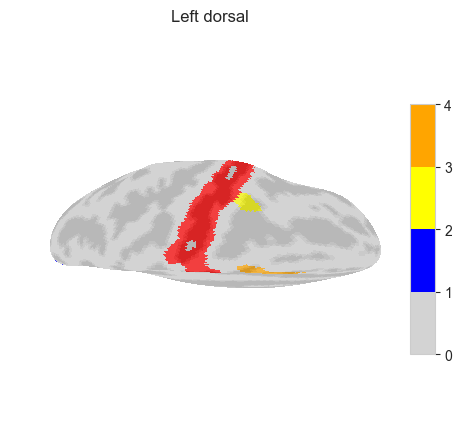

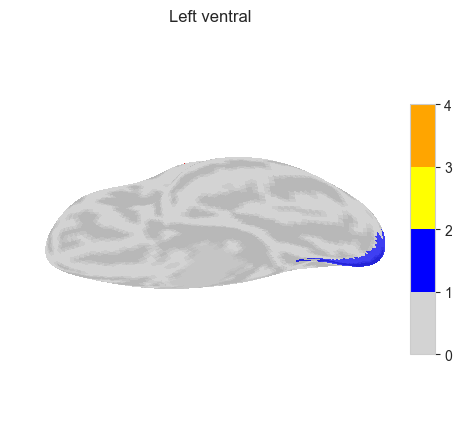

/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_16145/3867153056.py:58: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  fig = plotting.plot_surf_roi(


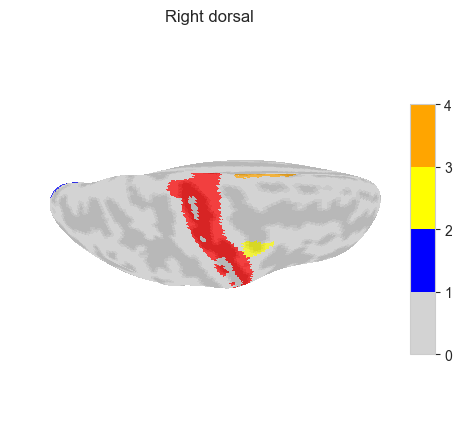

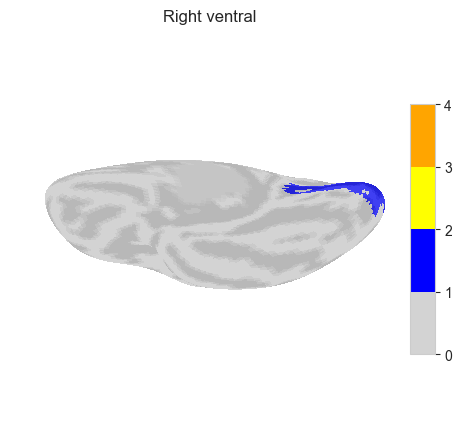

In [43]:
from matplotlib.colors import ListedColormap, BoundaryNorm, to_rgb
import numpy as np
import nilearn 
from mreyemove.analysis.glm.atlas import fetch_atlas
from nilearn import datasets, surface, plotting
from nilearn.surface.surface import load_surf_data

fsaverage = datasets.fetch_surf_fsaverage("fsaverage5")

atlas = fetch_atlas("glasser")
ROIS_TO_PLOT = {
    "V1":  ["L_V1_ROI", "R_V1_ROI"],
    # "V2": ["L_V2_ROI", "R_V2_ROI"],
    "SM":  [ "L_3a_ROI", "R_3a_ROI", "L_3b_ROI", "R_3b_ROI","L_4_ROI", "R_4_ROI",  ],
            # "L_1_ROI",  "R_1_ROI",  "L_2_ROI",  "R_2_ROI", "L_4_ROI", "R_4_ROI", "L_1_ROI",  "R_1_ROI",],
    # "SMA": ["L_6ma_ROI", "R_6ma_ROI", "L_6mp_ROI", "R_6mp_ROI", ],
    "FEF": ["L_FEF_ROI", "R_FEF_ROI",],
    "SEF": ["L_SCEF_ROI", "R_SCEF_ROI"],
    # "TPO": ["L_TPOJ1_ROI", "R_TPOJ1_ROI", "L_TPOJ2_ROI", "R_TPOJ2_ROI", "L_TPOJ3_ROI", "R_TPOJ3_ROI"]
}

atlas_data = atlas.maps.get_fdata()
combined = np.zeros(atlas_data.shape, dtype=np.int32)
roi_to_idx = {roi: i for i, roi in enumerate(atlas.labels, start=1)} 


for plot_idx, plot_name in enumerate(ROIS_TO_PLOT, start=1):
    roi_ids = [roi_to_idx[roi_name] for roi_name in ROIS_TO_PLOT[plot_name]]
    print("Looking for ROI IDS", roi_ids)
    combined[np.isin(atlas_data, roi_ids)] = plot_idx   
    
combined_img = nilearn.image.new_img_like(atlas.maps, combined, copy_header=True)

colors = ["lightgray", "blue", "red", "yellow", "orange"] #, "cyan", "magenta", "white"]
alpha = 1
rgba_colors = [(*to_rgb(c), alpha) for c in colors]
cmap = ListedColormap(rgba_colors)
# bounds = np.arange(-0.5, len(rgba_colors), 1)  # [-0.5, 0.5, 1.5, 2.5, ...]
# norm = BoundaryNorm(bounds, cmap.N)


n_rois  = len(ROIS_TO_PLOT)
roi_names = list(ROIS_TO_PLOT.keys())

for hemi, views in [("left", ["dorsal", "ventral"]), ("right", ["dorsal", "ventral"])]:
    pial    = fsaverage[f"infl_{hemi}"]
    sulcal  = fsaverage[f"sulc_{hemi}"]
    
    curv_map = load_surf_data(fsaverage[f"curv_{hemi}"])
    curv_sign_map = (np.sign(curv_map) + 1) / 4 + 0.25
    bg_map = curv_sign_map

    # project volume onto surface
    texture = surface.vol_to_surf(combined_img, fsaverage[f"pial_{hemi}"], interpolation="nearest_most_frequent", radius=4)
    # texture = np.round(texture).astype(np.int32).astype(np.float32)

    for view in views:
        fig = plotting.plot_surf_roi(
            surf_mesh=pial,
            roi_map=texture,
            hemi=hemi,
            view=view,
            bg_map=bg_map,
            bg_on_data=True,
            title=f"{hemi.capitalize()} {view}",
            colorbar=True,
            vmin=0,
            vmax=n_rois,
            cmap=cmap,
            # alpha=alpha,
        )
        # fig.savefig(f"roi_surface_{hemi}_{view}.png", dpi=150, bbox_inches="tight")
        plotting.show()
        

[fetch_atlas_harvard_oxford] Dataset found in /Users/zach/nilearn_data/fsl

/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_16145/765366723.py:59: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_roi(
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_16145/765366723.py:59: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_roi(
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_16145/765366723.py:59: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_roi(
/var/folders/30/pml2mkyx4cb4xgylttw3s24r0000gn/T/ipykernel_16145/765366723.py:59: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  plotting.plot_surf_roi(


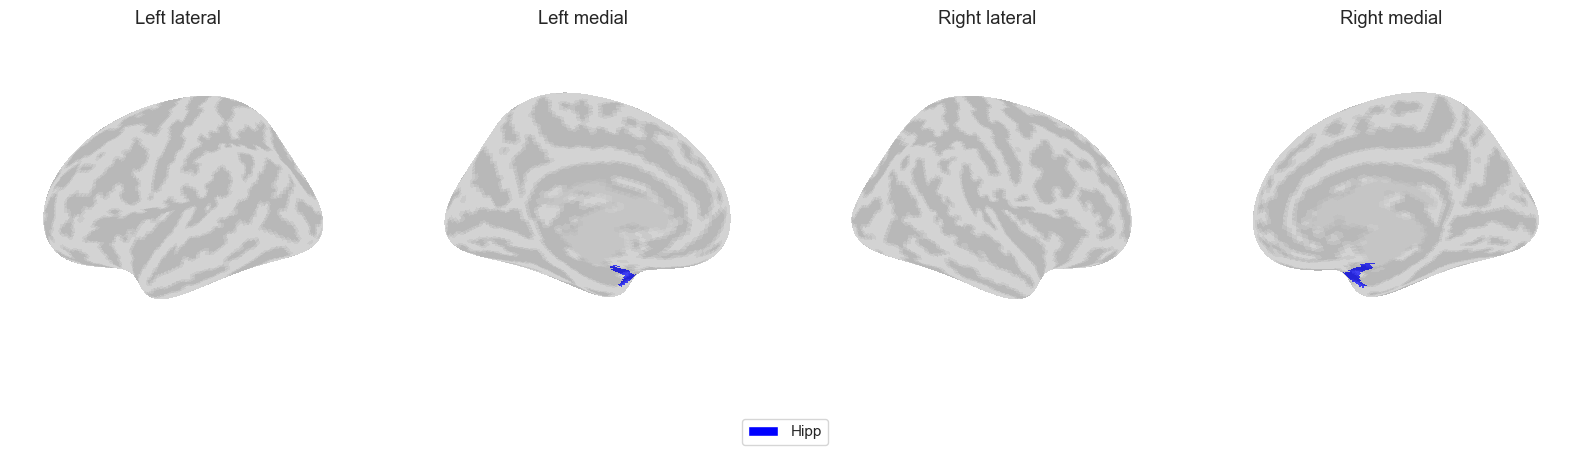

In [172]:

from matplotlib.colors import ListedColormap, to_rgb
import numpy as np
import nilearn
from mreyemove.analysis.glm.atlas import fetch_atlas
from nilearn import datasets, surface, plotting
from nilearn.surface.surface import load_surf_data
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fsaverage = datasets.fetch_surf_fsaverage("fsaverage5")

# atlas = fetch_atlas("glasser")
# ROIS_TO_PLOT = {
#   "Calc Sulc":  ["L_V1_ROI", "R_V1_ROI"],
#   "Cent Sulcus":  ["L_3a_ROI", "R_3a_ROI", "L_3b_ROI", "R_3b_ROI", "L_4_ROI", "R_4_ROI"],
#   "FEF": ["L_FEF_ROI", "R_FEF_ROI"],
#   "SEF": ["L_SCEF_ROI", "R_SCEF_ROI"],
# }
atlas = fetch_atlas("ho_sub")
ROIS_TO_PLOT = {
    "Hipp": ["Left Hippocampus", "Right Hippocampus"],
}

atlas_data = atlas.maps.get_fdata()
combined = np.zeros(atlas_data.shape, dtype=np.int32)
roi_to_idx = {roi: i for i, roi in enumerate(atlas.labels, start=1)}

for plot_idx, plot_name in enumerate(ROIS_TO_PLOT, start=1):
  roi_ids = [roi_to_idx[roi_name] for roi_name in ROIS_TO_PLOT[plot_name]]
  combined[np.isin(atlas_data, roi_ids)] = plot_idx

combined_img = nilearn.image.new_img_like(atlas.maps, combined, copy_header=True)

colors = ["lightgray", "blue",]# "red", "yellow", "orange"]
alpha = 1
rgba_colors = [(*to_rgb(c), alpha) for c in colors]
cmap = ListedColormap(rgba_colors)

n_rois = len(ROIS_TO_PLOT)
roi_names = list(ROIS_TO_PLOT.keys())

hemis_views = [
  ("left", "lateral"), ("left", "medial"),
  ("right", "lateral"), ("right", "medial"),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), subplot_kw={"projection": "3d"})

for ax, (hemi, view) in zip(axes, hemis_views):
  pial = fsaverage[f"infl_{hemi}"]
  curv_map = load_surf_data(fsaverage[f"curv_{hemi}"])
  bg_map = (np.sign(curv_map) + 1) / 4 + 0.25

  texture = surface.vol_to_surf(
      combined_img, fsaverage[f"pial_{hemi}"],
      interpolation="nearest_most_frequent", radius=4,
  )

  plotting.plot_surf_roi(
      surf_mesh=pial,
      roi_map=texture,
      hemi=hemi,
      view=view,
      bg_map=bg_map,
      bg_on_data=True,
      title=f"{hemi.capitalize()} {view}",
      colorbar=False,
      vmin=0,
      vmax=n_rois,
      cmap=cmap,
      figure=fig,
      axes=ax,
  )

legend_handles = [
  Patch(facecolor=colors[i + 1], label=name)
  for i, name in enumerate(roi_names)
]
fig.legend(handles=legend_handles, loc="lower center", ncol=n_rois, fontsize=11)
fig.subplots_adjust(bottom=0.12)
fig.savefig("/Users/zach/Desktop/roi_surface_all.png", dpi=300, bbox_inches="tight")
plt.show()


/Users/zach/.virtualenvs/sleepmreye/lib/python3.11/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



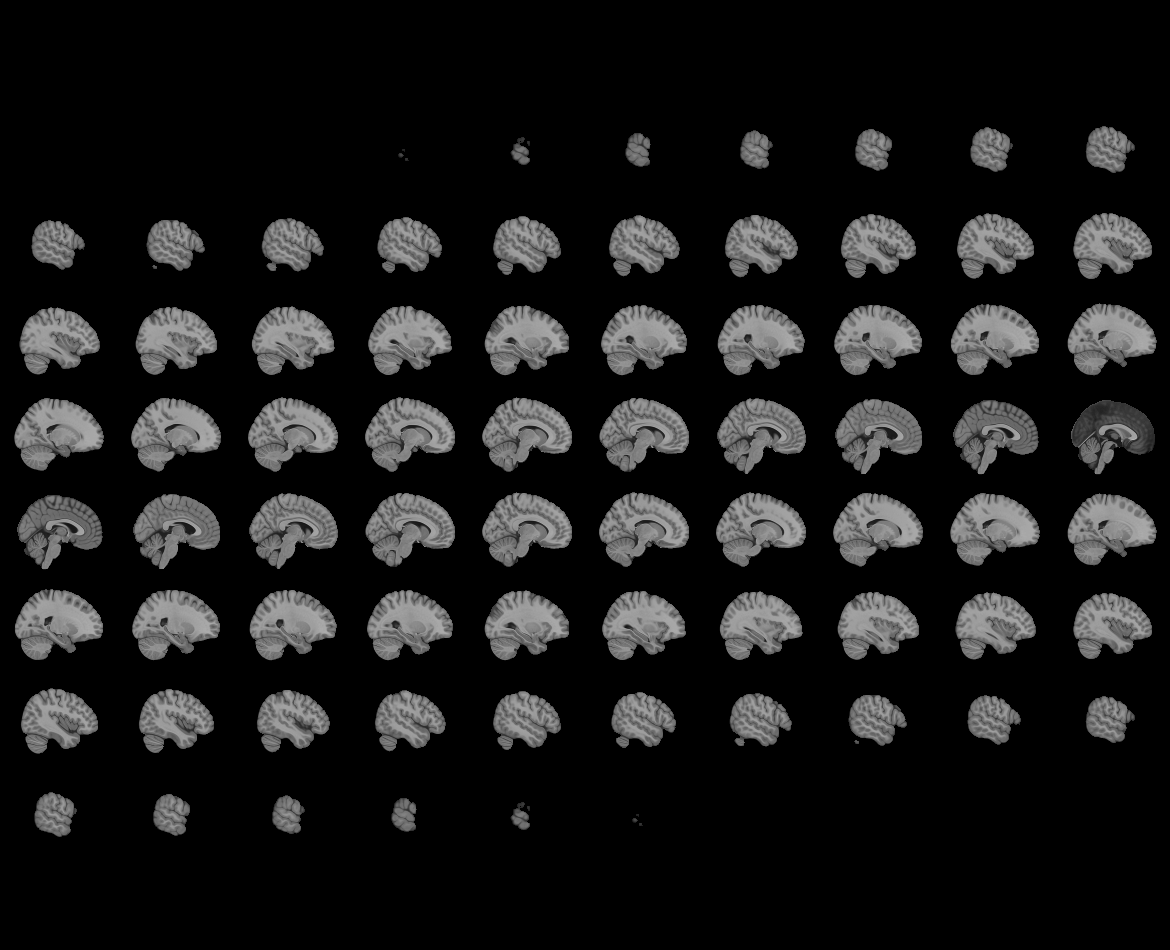
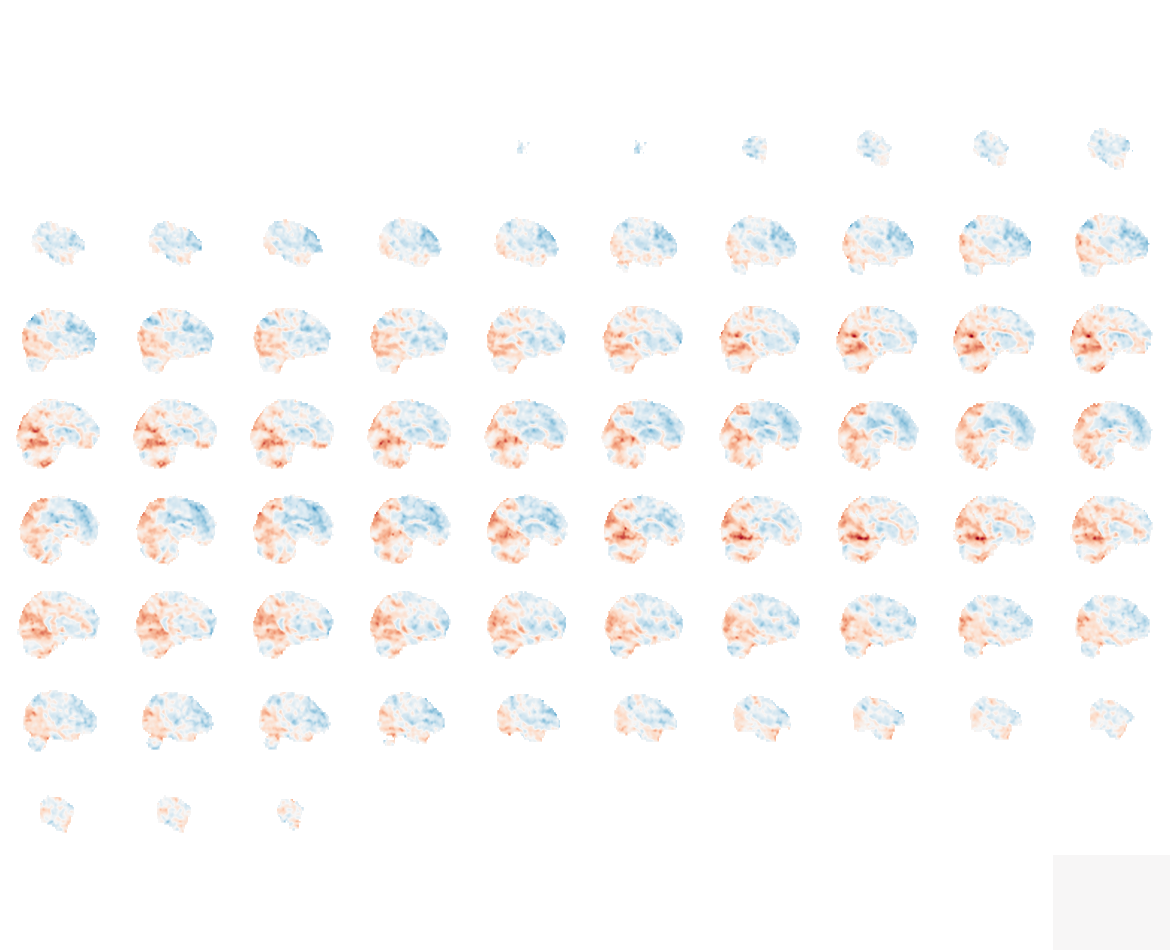

In [186]:

from nilearn import plotting

config = GLMConfig.from_yaml("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/designs/original_sleep.yml")
desc_add = construct_desc(dataset=mrio, config=config)
res, _ = mrio.load_FLAME_result(contrast="mreyemove_S", desc_add=desc_add)

# res, _ = mrio.load_subject_level_glm_data(subject="04", contrasts=["mreyemove_W"], desc_add=desc_add)

# res.keys()
# plotting.view_img(res["mreyemove_W"].stat, width_view=1200)
plotting.view_img(res.t_stat, width_view=1200)


In [43]:
import pandas as pd
from pathlib import Path
df = pd.read_csv(Path.home() / ".cache" / "atlases" / "cerebellum_retmaps"/ "cerebellum_retmaps.csv", header=None)
labels = df[1].values
labels

array(['right_lVIIIb', 'right_mVIIIb', 'left_mVIIIb', 'left_lVIIIb',
       'left_VIIb', 'right_VIIb', 'left_mOMV', 'left_lOMV', 'right_mOMV',
       'right_lOMV'], dtype=object)

Looking for ROI IDS [10, 190]


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

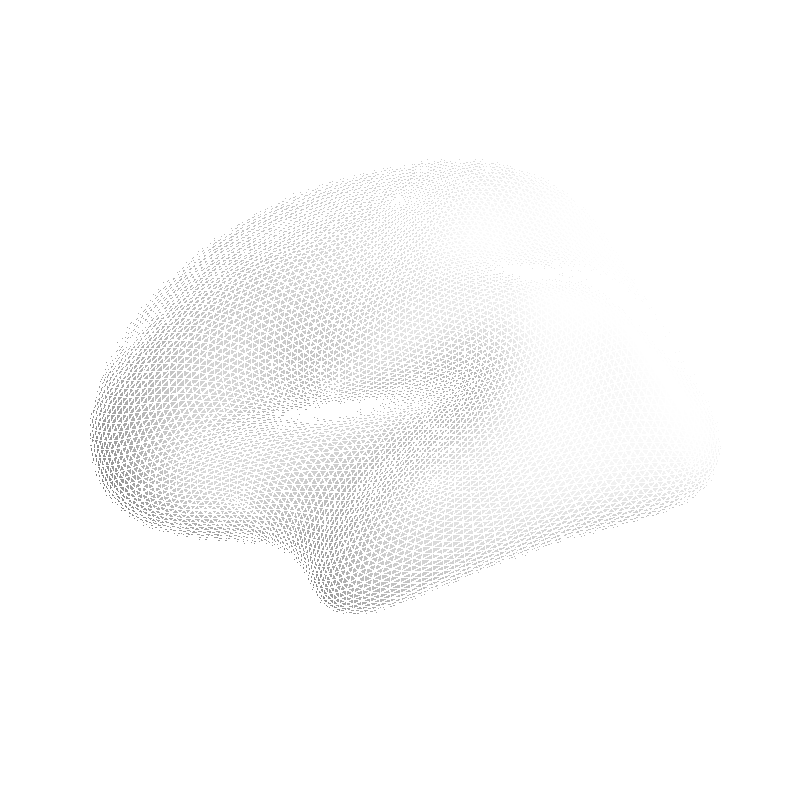

In [21]:

from matplotlib.colors import ListedColormap, BoundaryNorm

ROIS_TO_PLOT = {
    # "V1":  ["L_V1_ROI", "R_V1_ROI"],
    # "V2": ["L_V2_ROI", "R_V2_ROI"],
    # "SM":  ["L_4_ROI", "R_4_ROI", "L_3a_ROI", "R_3a_ROI", "L_3b_ROI", "R_3b_ROI",
    #         "L_1_ROI",  "R_1_ROI",  "L_2_ROI",  "R_2_ROI"],
    # "SMA": ["L_6ma_ROI", "R_6ma_ROI", "L_6mp_ROI", "R_6mp_ROI", "L_SCEF_ROI", "R_SCEF_ROI"],
    "EF": ["L_FEF_ROI", "R_FEF_ROI",],
    # "TPO": ["L_TPOJ1_ROI", "R_TPOJ1_ROI", "L_TPOJ2_ROI", "R_TPOJ2_ROI", "L_TPOJ3_ROI", "R_TPOJ3_ROI"]
}

atlas_data = atlas.maps.get_fdata()
combined = np.zeros(atlas_data.shape, dtype=np.int32)
roi_to_idx = {roi: i for i, roi in enumerate(atlas.labels, start=1)} 


for plot_idx, plot_name in enumerate(ROIS_TO_PLOT, start=1):
    roi_ids = [roi_to_idx[roi_name] for roi_name in ROIS_TO_PLOT[plot_name]]
    print("Looking for ROI IDS", roi_ids)
    combined[np.isin(atlas_data, roi_ids)] = plot_idx   
    
combined_img = nilearn.image.new_img_like(atlas.maps, combined, copy_header=True)

colors = ["lightgray", "blue", "red", "yellow", "orange", "cyan", "magenta", "white"]
cmap = ListedColormap(colors)
bounds = np.arange(-0.5, len(colors), 1)  # [-0.5, 0.5, 1.5, 2.5, ...]
norm = BoundaryNorm(bounds, cmap.N)


plot_surface_rois(
    combined_img,
    surf_mesh="fsaverage5",
    inflate=True,
    cmap=norm,
)
# plotting.plot_img_on_surf(
#     stat_map=combined_img,
#     cmap="Set1",
#     inflate=True,
#     # hemispheres=["right"],
#     threshold=0.1,
#     # views=["lateral"],
# )
# plotting.plot_roi(
#     combined_img,
#     # title=str({i: roi for i, roi in enumerate(ROIS_TO_PLOT, start=1)}),
#     display_mode="ortho",
#     draw_cross=False,
#     cmap="tab10",
# )
# print({i: roi for i, roi in enumerate(ROIS_TO_PLOT, start=1)})

# plotting.show()

In [13]:
import nibabel as nib
import numpy as np


for contrast in ['mreyemove_1', 'mreyemove_2']:
  data, _ = mrio.load_randomise_result(contrast=contrast, desc_add=desc_add)
  t = data.t_stat_pos.get_fdata()
  print(f"{contrast}: max t={t.max():.2f}, mean abs t={np.abs(t[t!=0]).mean():.2f}")

mreyemove_1: max t=5.44, mean abs t=0.78
mreyemove_2: max t=4.70, mean abs t=0.77
